In [13]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as mpl
data = pd.read_csv("./winning_deck_results.csv", index_col=0)
# Turn the won column into boolean
data['won'] = data['won'].map({' True': True, ' False': False})
data.head()

,num_moves,won,x0,x1,x2,x3,x4,x5,x6,x7,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51
deck,,,,,,,,,,,,,,,,,,,,,
0,138,True,29,13,46,42,39,8,6,37,...,31,20,26,32,33,17,3,27,49,25
1,21,False,50,10,38,23,3,39,20,12,...,42,31,29,32,8,17,5,49,37,9
2,43,False,16,30,10,22,5,7,52,27,...,14,39,17,20,43,11,24,51,6,4
3,2,False,14,29,4,20,30,27,52,23,...,5,51,41,31,39,24,9,35,38,16
4,23,False,38,23,40,22,17,52,29,51,...,2,5,6,10,31,26,47,7,20,16


In [5]:
visible_cards = data.iloc[:, [2, 9, 17, 20, 24, 27, 29]]
deck_cards = data.iloc[:, 30:]
known_cards = pd.concat([visible_cards, deck_cards], axis=1)
known_cards.columns = range(known_cards.shape[1])
known_cards.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
deck,,,,,,,,,,,,,,,,,,,,,
0,29,37,15,35,43,11,28,51,24,4,...,31,20,26,32,33,17,3,27,49,25
1,50,12,47,41,33,27,11,34,4,19,...,42,31,29,32,8,17,5,49,37,9
2,16,27,31,21,47,15,1,40,2,34,...,14,39,17,20,43,11,24,51,6,4
3,14,23,49,2,22,44,28,43,21,8,...,5,51,41,31,39,24,9,35,38,16
4,38,51,13,33,30,42,27,1,32,9,...,2,5,6,10,31,26,47,7,20,16


In [6]:
max_loss = data.loc[data['won'] == False, 'num_moves'].max()
min_win = data.loc[data['won'] == True, 'num_moves'].min()
print("Maximum moves to loss:", max_loss, " | Minimum moves to win:", min_win)

Maximum moves to loss: 115  | Minimum moves to win: 113


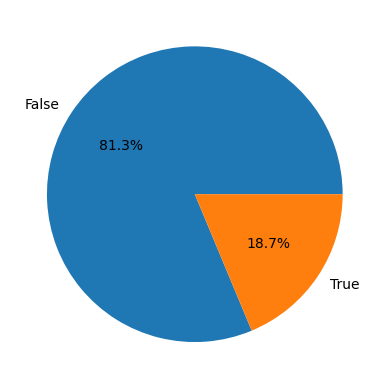

In [25]:
wins = data['won'].value_counts()
mpl.pie(wins, labels=wins.index, autopct='%1.1f%%')
mpl.show()

In [7]:
known_cards = known_cards.iloc[:, 2:].fillna(0)

card_ids = data.values.astype(int)

mask = card_ids > 0

card_ids_adj = np.where(mask, card_ids - 1, 0)

suits = card_ids_adj // 13
ranks = (card_ids_adj % 13)

colors = np.where(suits < 2, 0, 1)

# handle unknowns
ranks[~mask] = 0
suits[~mask] = -1
colors[~mask] = -1

cols = []
for i, col in enumerate(known_cards.columns):
    cols.append(pd.DataFrame({
        f"{col}_rank": ranks[:, i],
        f"{col}_suit": suits[:, i],
        f"{col}_color": colors[:, i],
    }))

remapped = pd.concat(cols, axis=1)
remapped.head()

,2_rank,2_suit,2_color,3_rank,3_suit,3_color,4_rank,4_suit,4_color,5_rank,...,27_color,28_rank,28_suit,28_color,29_rank,29_suit,29_color,30_rank,30_suit,30_color
0,7,10,1,0,0,0,2,2,1,12,...,0,2,1,0,10,0,0,8,1,0
1,7,1,0,0,-1,-1,10,3,1,9,...,0,12,1,0,0,2,1,8,2,1
2,3,3,1,0,-1,-1,2,1,0,3,...,0,2,3,1,1,1,0,11,0,0
3,1,0,0,0,-1,-1,0,1,0,2,...,1,8,3,1,4,3,1,2,3,1
4,9,1,0,0,-1,-1,11,2,1,9,...,0,9,3,1,2,3,1,7,1,0


In [8]:
def count_valid_moves(ranks, colors):
    moves = 0
    n = len(ranks)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            if (
                ranks[i] > 0 and ranks[j] > 0 and
                colors[i] != colors[j] and
                ranks[i] == ranks[j] - 1
            ):
                moves += 1

    return moves
move_counts = []

for row in range(ranks.shape[0]):
    move_counts.append(count_valid_moves(ranks[row], colors[row]))

remapped["num_valid_moves"] = move_counts

In [9]:
from sklearn.preprocessing import StandardScaler as StdS
from sklearn.linear_model import LogisticRegression as LReg
from sklearn.neural_network import MLPClassifier as MLP
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier as GPC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier as DTree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.model_selection import cross_val_score
from alive_progress import alive_bar
from sklearn.preprocessing import LabelEncoder as le

In [10]:
X = remapped.values
y = data.iloc[:, 1].astype(int)
sc = StdS()
sc.fit(X)
X_sc = sc.transform(X)

In [11]:
import numpy as np
print(np.mean(y))

0.1871


# K Nearest Neighbors
Change `folds_to_test` and `neighbors_to_test` to modify the tests

|                                        | ▁▃▅ 0/128 [0%] in 0s (~0s, 0.0/s) 

|████████████████████████████████████████| 128/128 [100%] in 54.9s (2.33/s)     
     Neighbors  Accuracy  Standard Deviation
0          3.0    0.9885            0.003138
1          4.0    0.9779            0.003270
2          5.0    0.9926            0.002498
3          6.0    0.9870            0.003742
4          7.0    0.9958            0.001833
..         ...       ...                 ...
123      126.0    0.9999            0.000300
124      127.0    0.9999            0.000300
125      128.0    0.9999            0.000300
126      129.0    0.9999            0.000300
127      130.0    0.9998            0.000400

[128 rows x 3 columns]
        Neighbors    Accuracy  Standard Deviation
count  128.000000  128.000000          128.000000
mean    66.500000    0.998995            0.000704
std     37.094474    0.002693            0.000722
min      3.000000    0.977900            0.000000
25%     34.750000    0.999400            0.000300
50%     66.500000    0.999700            0.000458
75%  

<Axes: xlabel='Neighbors', ylabel='Accuracy'>

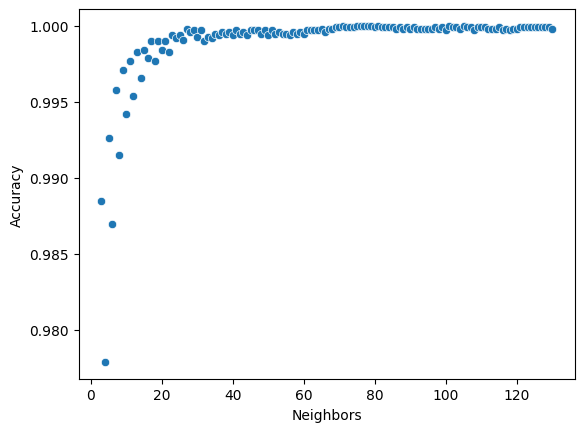

In [12]:
neighbors_to_test: int = 128
# K Nearest Neighbors Test
knn_results = pd.DataFrame(columns=['Neighbors', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(neighbors_to_test, force_tty=True) as bar:
    # Test different neighbors
    for i in range(3, neighbors_to_test+3):
        cvs = cross_val_score(KNN(i), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        knn_results.loc[len(knn_results)] = [i, mean, std]
        bar()
print(knn_results)
print(knn_results.describe())
print(knn_results.iloc[[int(knn_results['Accuracy'].idxmax())]])
sns.scatterplot(knn_results,x='Neighbors', y='Accuracy')

# Linear SVC
Add or remove from `tests_to_run` to change the number of tests

|████████████████████████████████████████| 6/6 [100%] in 11.3s (0.44/s)         
         C  Accuracy  Standard Deviation
0   0.0001       1.0                 0.0
1   0.0010       1.0                 0.0
2   0.0100       1.0                 0.0
3   0.1000       1.0                 0.0
4   1.0000       1.0                 0.0
5  10.0000       1.0                 0.0
               C  Accuracy  Standard Deviation
count   6.000000       6.0                 6.0
mean    1.851850       1.0                 0.0
std     4.010836       0.0                 0.0
min     0.000100       1.0                 0.0
25%     0.003250       1.0                 0.0
50%     0.055000       1.0                 0.0
75%     0.775000       1.0                 0.0
max    10.000000       1.0                 0.0
        C  Accuracy  Standard Deviation
0  0.0001       1.0                 0.0


<Axes: xlabel='C', ylabel='Accuracy'>

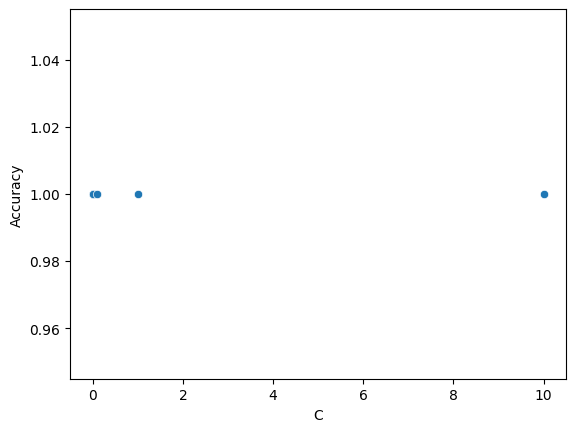

In [13]:
tests_to_run = [.0001, .001, .01, .1, 1.0, 10.0]
# Linear SVC Test
lsvc_results = pd.DataFrame(columns=['C', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(len(tests_to_run), force_tty=True) as bar:
        # Test different neighbors
        for i in tests_to_run:
            cvs = cross_val_score(SVC(C=i, kernel="linear"), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            lsvc_results.loc[len(lsvc_results)] = [i, mean, std]
            bar()
print(lsvc_results)
print(lsvc_results.describe())
print(lsvc_results.iloc[[int(lsvc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=lsvc_results,x='C',y='Accuracy')

# SVC
Change `gamma_to_test` to change the number of tests

Uses `tests_to_run` from before

|████████████████████████████████████████| 96/96 [100%] in 52:14.0 (0.03/s)     
          C  Gamma  Accuracy  Standard Deviation
0    0.0001    0.0    0.8129              0.0003
1    0.0001    1.0    0.8129              0.0003
2    0.0001    2.0    0.8129              0.0003
3    0.0001    3.0    0.8129              0.0003
4    0.0001    4.0    0.8129              0.0003
..      ...    ...       ...                 ...
91  10.0000   11.0    0.8129              0.0003
92  10.0000   12.0    0.8129              0.0003
93  10.0000   13.0    0.8129              0.0003
94  10.0000   14.0    0.8129              0.0003
95  10.0000   15.0    0.8129              0.0003

[96 rows x 4 columns]
               C      Gamma  Accuracy  Standard Deviation
count  96.000000  96.000000   96.0000             96.0000
mean    1.851850   7.500000    0.8129              0.0003
std     3.680595   4.633971    0.0000              0.0000
min     0.000100   0.000000    0.8129              0.0003
25%     0.001000  

<Axes: xlabel='Gamma', ylabel='Accuracy'>

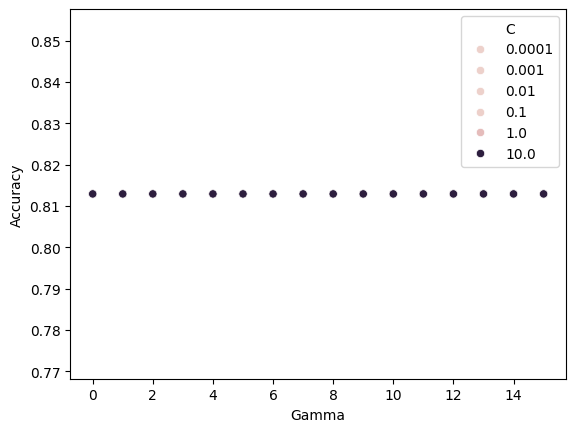

In [14]:
gamma_to_test: int = 16
# SVC Test
svc_results = pd.DataFrame(columns=['C', 'Gamma', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(len(tests_to_run)*gamma_to_test, force_tty=True) as bar:
    for i in tests_to_run:
        for k in range(gamma_to_test):
            cvs = cross_val_score(SVC(C=i, gamma=gamma_to_test), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            svc_results.loc[len(svc_results)] = [i, k, mean, std]
            bar()
print(svc_results)
print(svc_results.describe())
print(svc_results.iloc[[int(svc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=svc_results,x='Gamma',hue='C',y='Accuracy')

|████████████████████████████████████████| 256/256 [100%] in 1:12.4 (3.53/s)    
     depth  Accuracy  Standard Deviation
0      1.0       1.0                 0.0
1      2.0       1.0                 0.0
2      3.0       1.0                 0.0
3      4.0       1.0                 0.0
4      5.0       1.0                 0.0
..     ...       ...                 ...
251  252.0       1.0                 0.0
252  253.0       1.0                 0.0
253  254.0       1.0                 0.0
254  255.0       1.0                 0.0
255  256.0       1.0                 0.0

[256 rows x 3 columns]
            depth  Accuracy  Standard Deviation
count  256.000000     256.0               256.0
mean   128.500000       1.0                 0.0
std     74.045031       0.0                 0.0
min      1.000000       1.0                 0.0
25%     64.750000       1.0                 0.0
50%    128.500000       1.0                 0.0
75%    192.250000       1.0                 0.0
max    256.000000  

<Axes: xlabel='depth', ylabel='Accuracy'>

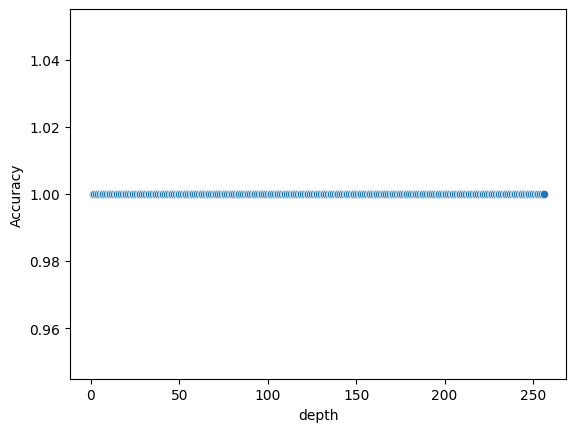

In [15]:
depth: int = 256
# Tree Test
dtree_results = pd.DataFrame(columns=['depth', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(depth, force_tty=True) as bar:
    for i in range(1, depth+1):
        cvs = cross_val_score(DTree(max_depth=i), X, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        dtree_results.loc[len(dtree_results)] = [i, mean, std]
        bar()
print(dtree_results)
print(dtree_results.describe())
print(dtree_results.iloc[[int(dtree_results['Accuracy'].idxmax())]])
sns.scatterplot(data=dtree_results,x='depth',y='Accuracy')

|████████████████████████████████████████| 512/512 [100%] in 3:07.6 (2.73/s)    
     estimators  features  Accuracy  Standard Deviation
0           1.0       1.0    0.8129              0.0003
1           1.0       2.0    0.8129              0.0003
2           1.0       3.0    0.8129              0.0003
3           1.0       4.0    0.8129              0.0003
4           1.0       5.0    0.8129              0.0003
..          ...       ...       ...                 ...
507        64.0       4.0    0.8129              0.0003
508        64.0       5.0    0.8129              0.0003
509        64.0       6.0    0.8129              0.0003
510        64.0       7.0    0.8129              0.0003
511        64.0       8.0    0.8129              0.0003

[512 rows x 4 columns]
       estimators    features    Accuracy  Standard Deviation
count   512.00000  512.000000  512.000000          512.000000
mean     32.50000    4.500000    0.813191            0.001024
std      18.49102    2.293529    0.00

<Axes: xlabel='estimators', ylabel='Accuracy'>

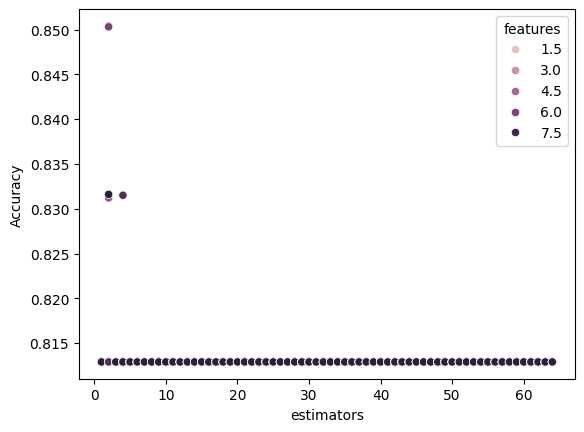

In [ ]:
estimators: int = 64
features: int = 8
# Tree Test
rforest_results = pd.DataFrame(columns=['estimators', 'features', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(estimators*features, force_tty=True) as bar:
    for o in range(1, estimators+1):
        for u in range(1, features+1):
            cvs = cross_val_score(RandomForestClassifier(max_depth=1, n_estimators=o, max_features=1), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            rforest_results.loc[len(rforest_results)] = [o, u, mean, std]
            bar()
print(rforest_results)
print(rforest_results.describe())
print(rforest_results.iloc[[int(rforest_results['Accuracy'].idxmax())]])
sns.scatterplot(data=rforest_results,x='estimators',hue='features',y='Accuracy')
iterations: int = 32768
alpha: int = 16
# MLP Test
mlp_results = pd.DataFrame(columns=['Alpha', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(alpha, force_tty=True) as bar:
    for i in range(1, alpha+1):
        cvs = cross_val_score(MLP(alpha=o,max_iter=iterations), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        mlp_results.loc[len(mlp_results)] = [i, mean, std]
        bar()
print(mlp_results)
print(mlp_results.describe())
print(mlp_results.iloc[[int(mlp_results['Accuracy'].idxmax())]])
sns.scatterplot(data=mlp_results,x='Alpha',y='Accuracy')

In [18]:
# Ada Test
cvs = cross_val_score(AdaBoostClassifier(), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", str(std))

Mean: 1.0 | Std: 0.0


In [19]:
# Gaussian Test
cvs = cross_val_score(GaussianNB(), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", std)

Mean: 1.0 | Std: 0.0


|                                        | ▁▃▅ 0/3072 [0%] in 0s (~0s, 0.0/s) 

|██████████████████████████▋             | ▅▃▁ 2048/3072 [67%] in 13:59 (~6:50, 

/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitai

|██████████████████████████▋             | ▁▃▅ 2049/3072 [67%] in 13:59 (~6:50, 

/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitai

|████████████████████████████████████████| ▇▇▅ 3071/3072 [100%] in 47:27 (~1s, 1

/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


|████████████████████████████████████████| 3072/3072 [100%] in 47:27.5 (1.08/s) 
     Solver  State  Accuracy  Standard Deviation
0     lbfgs      1       1.0                 0.0
1     lbfgs      2       1.0                 0.0
2     lbfgs      3       1.0                 0.0
3     lbfgs      4       1.0                 0.0
4     lbfgs      5       1.0                 0.0
...     ...    ...       ...                 ...
3067   saga    508       1.0                 0.0
3068   saga    509       1.0                 0.0
3069   saga    510       1.0                 0.0
3070   saga    511       1.0                 0.0
3071   saga    512       1.0                 0.0

[3072 rows x 4 columns]
             State  Accuracy  Standard Deviation
count  3072.000000    3072.0              3072.0
mean    256.500000       1.0                 0.0
std     147.825449       0.0                 0.0
min       1.000000       1.0                 0.0
25%     128.750000       1.0                 0.0
50%     256.

<Axes: xlabel='State', ylabel='Accuracy'>

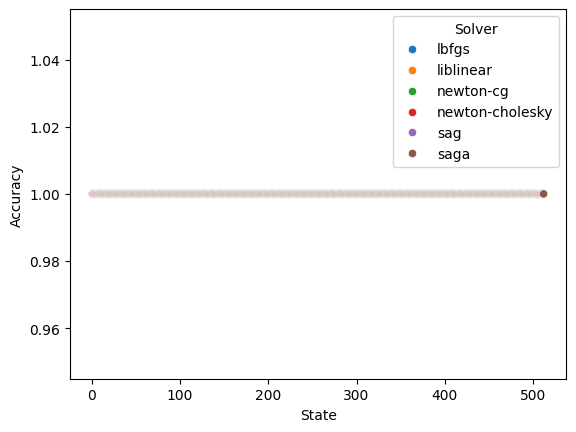

In [20]:
state: int = 512
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
# LReg Test
lreg_results = pd.DataFrame(columns=['Solver', 'State', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(state*len(solver), force_tty=True) as bar:
    for o in solver:
        for i in range(1, state+1):
            cvs = cross_val_score(LReg(random_state=state, solver=o), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            lreg_results.loc[len(lreg_results)] = [o, i, mean, std]
            bar()
print(lreg_results)
print(lreg_results.describe())
print(lreg_results.iloc[[int(lreg_results['Accuracy'].idxmax())]])
sns.scatterplot(data=lreg_results,x='State',y='Accuracy',hue='Solver')

/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.wa

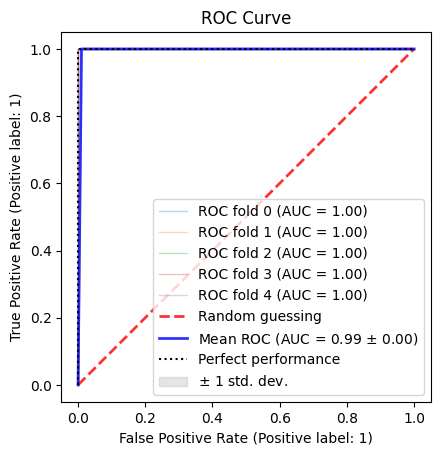

In [21]:
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
X_train = X_sc
cv = StratifiedKFold(n_splits=5) # just to 5 fold
classifier = LogisticRegression(random_state=1, solver='lbfgs')
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
fig, ax = plt.subplots()

# create and add ROC for each  fold
for i, (train, test) in enumerate(cv.split(X_train, y)): # iterator
    classifier.fit(X_train[train], y[train])
    viz = RocCurveDisplay.from_estimator(classifier, X_train[test], y[test],
                         name=f'ROC fold {i}',
                         alpha=0.3, lw=1, ax=ax)
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

# add curve for random guessing
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Random guessing', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# add curve for mean scores
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

# add curve for a perfect score
ax.plot([0, 0, 1],
        [0, 1, 1], linestyle=':', color='black', label='Perfect performance')

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC Curve")
ax.legend(loc="lower right")
plt.show()